# ML Starter Kit — End-to-End Workflow

This notebook demonstrates the **entire** ML Starter Kit, start to finish, on a small
customer churn dataset. Every step uses a reusable function from `src/` — no boilerplate
preprocessing or model code is written directly in this notebook.

**The 16-step workflow:**
1. Import libraries
2. Load data
3. Identify X/y
4. Train/test split
5. Identify numerical/categorical features
6. Build preprocessing
7. Select model
8. Build pipeline
9. Train
10. Cross-validation
11. Hyperparameter tuning
12. Evaluate
13. Feature importance
14. Save model
15. Load model
16. Predict new data

## 1. Import libraries

In [1]:
import sys
sys.path.insert(0, "..")  # so `src` is importable from the notebooks/ folder

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.data.splitter import split_data
from src.preprocessing.pipeline import build_preprocessor, build_pipeline
from src.models.factory import get_model, list_available_models
from src.evaluation.metrics import evaluate_model
from src.evaluation.cross_validation import cross_validate_model
from src.evaluation.model_selection import tune_model, compare_models
from src.evaluation.importance import get_feature_names, permutation_feature_importance
from src.utils.io import save_model, load_model, predict, predict_proba
from src.utils.visualization import plot_confusion_matrix, plot_roc_curve, plot_feature_importance
from src.utils.config import load_config

print("All framework modules imported successfully.")

All framework modules imported successfully.


## 2. Load data

In [2]:
config = load_config("../configs/config.yaml")
print(config)

{'data': {'path': 'data/raw/customer_churn.csv', 'target': 'churn'}, 'split': {'test_size': 0.2, 'random_state': 42, 'stratify': True}, 'preprocessing': {'numeric_strategy': 'median', 'scaler': 'standard', 'categorical_encoder': 'onehot', 'categorical_imputation': 'most_frequent'}, 'model': {'name': 'logistic', 'parameters': {'C': 1.0, 'max_iter': 1000, 'random_state': 42}}, 'evaluation': {'cv': 5, 'scoring': 'roc_auc', 'stratified': True}, 'tuning': {'param_grid': {'model__C': [0.01, 0.1, 1.0, 10.0]}}}


In [3]:
df = load_data(f"../{config['data']['path']}")

[07:09:30] INFO     src.data.loader: Loaded 'customer_churn.csv' as csv -> shape=(600, 8)


DATA SUMMARY
Rows: 600   Columns: 8
Duplicate rows: 0

Dtypes:
int64      3
float64    3
object     2

Missing values (columns with at least one):
income    60
age       30
city      18


## 3. Identify X/y and 4. Train/test split

In [4]:
# split_data() separates X/y AND splits into train/test in one call -- and it does this
# BEFORE any preprocessing is fit, which is exactly what prevents preprocessing leakage
# (see src/data/splitter.py's WHY section for the full explanation).
X_train, X_test, y_train, y_test = split_data(
    df.drop(columns=["customer_id"]),
    target=config["data"]["target"],
    test_size=config["split"]["test_size"],
    random_state=config["split"]["random_state"],
    stratify=config["split"]["stratify"],
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

[07:09:30] INFO     src.data.splitter: Split data: train=(480, 6), test=(120, 6), stratified=True


Train: (480, 6), Test: (120, 6)


## 5. Identify numerical/categorical features

In [5]:
numerical_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['age', 'income', 'monthly_spend', 'support_calls']
Categorical: ['contract_type', 'city']


## 6. Build preprocessing

In [6]:
preprocessor = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    numeric_strategy=config["preprocessing"]["numeric_strategy"],
    scaler=config["preprocessing"]["scaler"],
    categorical_encoder=config["preprocessing"]["categorical_encoder"],
    categorical_imputation=config["preprocessing"]["categorical_imputation"],
)
preprocessor

[07:09:30] INFO     src.preprocessing.pipeline: Built preprocessor: 4 numeric, 2 categorical columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## 7. Select model

In [7]:
print("Available models:", list_available_models())

model = get_model(config["model"]["name"], **config["model"]["parameters"])
model

Available models: {'regression': ['decision_tree_regressor', 'elasticnet', 'gradient_boosting_regressor', 'lasso', 'linear', 'linear_regression', 'random_forest_regressor', 'ridge'], 'classification': ['decision_tree_classifier', 'gradient_boosting_classifier', 'knn', 'logistic', 'logistic_regression', 'random_forest_classifier', 'svm']}
[07:09:31] INFO     src.models.factory: Created model: logistic -> LogisticRegression({'C': 1.0, 'max_iter': 1000, 'random_state': 42})


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 8. Build pipeline

In [8]:
pipeline = build_pipeline(preprocessor, model)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 9. Train

In [9]:
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully.")

Pipeline fitted successfully.


## 10. Cross-validation

In [10]:
cv_results = cross_validate_model(
    pipeline, X_train, y_train,
    cv=config["evaluation"]["cv"],
    scoring=config["evaluation"]["scoring"],
    stratified=config["evaluation"]["stratified"],
)
print("Fold scores:", cv_results["scores"].round(4))
print(f"Mean: {cv_results['mean']:.4f}  Std: {cv_results['std']:.4f}")

[07:09:31] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.7439, std=0.0063


Fold scores: [0.7557 0.7383 0.7422 0.7388 0.7443]
Mean: 0.7439  Std: 0.0063


## 11. Hyperparameter tuning

In [11]:
tuning_result = tune_model(
    pipeline,
    param_grid=config["tuning"]["param_grid"],
    X=X_train, y=y_train,
    cv=config["evaluation"]["cv"],
    scoring=config["evaluation"]["scoring"],
)
print("Best params:", tuning_result["best_params_"])
print(f"Best CV score: {tuning_result['best_score_']:.4f}")

best_pipeline = tuning_result["best_estimator_"]
tuning_result["cv_results_"][["param_model__C", "mean_test_score", "std_test_score", "rank_test_score"]].head()

[07:09:31] INFO     src.evaluation.model_selection: GridSearchCV best score: 0.7320, best params: {'model__C': 1.0}


Best params: {'model__C': 1.0}
Best CV score: 0.7320


,param_model__C,mean_test_score,std_test_score,rank_test_score
2,1.00,0.732034,0.035549,1
3,10.00,0.731361,0.035285,2
1,0.10,0.730522,0.037890,3
0,0.01,0.716786,0.037798,4


## 12. Evaluate

In [12]:
results = evaluate_model(best_pipeline, X_test, y_test, task="classification")
results

[07:09:31] INFO     src.evaluation.metrics: Evaluation (classification): {'Accuracy': 0.6833333333333333, 'Precision': 0.5666666666666667, 'Recall': 0.40476190476190477, 'F1': 0.4722222222222222, 'ROC_AUC': 0.6651404151404152}


{'Accuracy': 0.6833333333333333,
 'Precision': 0.5666666666666667,
 'Recall': 0.40476190476190477,
 'F1': 0.4722222222222222,
 'ROC_AUC': 0.6651404151404152}

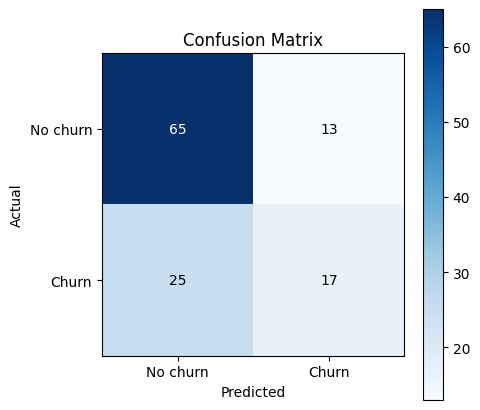

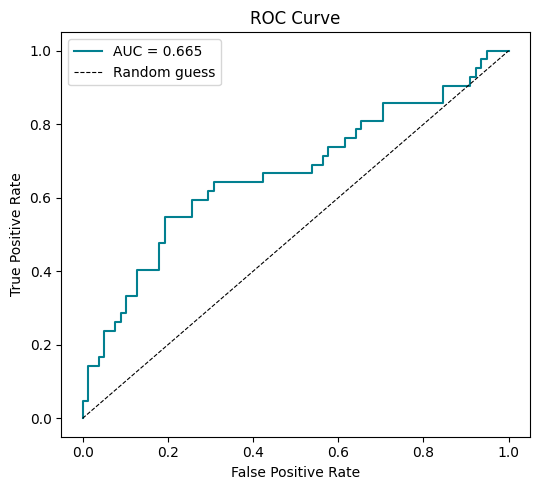

In [13]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

fig1 = plot_confusion_matrix(y_test, y_pred, labels=["No churn", "Churn"])
plt.show()

fig2 = plot_roc_curve(y_test, y_proba)
plt.show()

## 13. Feature importance

We use `get_feature_names()` to correctly recover the REAL feature names after the
`ColumnTransformer` (which one-hot-encoded `contract_type` and `city` into several columns
each) -- then compute permutation importance, which works regardless of model type.

In [14]:
feature_names = get_feature_names(best_pipeline)
print(f"{len(feature_names)} features after preprocessing:")
print(feature_names)

12 features after preprocessing:
['age', 'income', 'monthly_spend', 'support_calls', 'contract_type_Month-to-month', 'contract_type_One year', 'contract_type_Two year', 'city_Bengaluru', 'city_Chennai', 'city_Delhi', 'city_Mumbai', 'city_Pune']


In [15]:
# Permutation importance must be computed at a CONSISTENT feature granularity: since
# feature_names above is the EXPANDED, post-one-hot-encoding list (12 columns), we apply
# permutation importance to the model step on the PREPROCESSED test data -- not the raw
# 6-column X_test -- so the importances array lines up with feature_names correctly.
X_test_processed = best_pipeline.named_steps["preprocessor"].transform(X_test)

importance_df = permutation_feature_importance(
    best_pipeline.named_steps["model"], X_test_processed, y_test,
    feature_names=feature_names, n_repeats=15, scoring="roc_auc",
)
importance_df.head(10)

,feature,importance_mean,importance_std
0,support_calls,0.059361,0.034446
1,contract_type_Month-to-month,0.033089,0.014649
2,income,0.028755,0.015445
3,monthly_spend,0.026048,0.025465
4,contract_type_Two year,0.009503,0.007922
5,contract_type_One year,0.002259,0.001897
6,city_Pune,0.001445,0.002765
7,city_Chennai,0.000590,0.000645
8,city_Mumbai,0.000285,0.000324
9,city_Bengaluru,-0.000183,0.003894


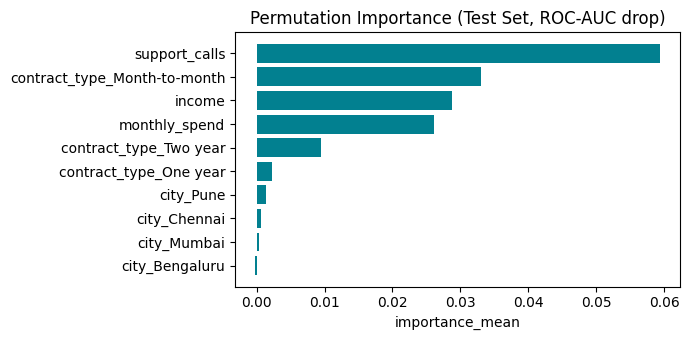

In [16]:
fig3 = plot_feature_importance(importance_df, top_n=10, title="Permutation Importance (Test Set, ROC-AUC drop)")
plt.show()

## 14. Save model

In [17]:
save_model(best_pipeline, "../models/churn_model.joblib")

[07:09:32] INFO     src.utils.io: Saved model to '../models/churn_model.joblib'


## 15. Load model

In [18]:
loaded_pipeline = load_model("../models/churn_model.joblib")
print(type(loaded_pipeline))

[07:09:32] INFO     src.utils.io: Loaded model from '../models/churn_model.joblib'


<class 'sklearn.pipeline.Pipeline'>


## 16. Predict new data

The pipeline expects RAW input — the exact same raw column structure as training data.
Imputation, scaling, and encoding all happen automatically inside `.predict()`.

In [19]:
new_customers = pd.DataFrame([
    {"age": 29, "income": 42000, "monthly_spend": 55.0, "contract_type": "Month-to-month",
     "city": "Mumbai", "support_calls": 4},
    {"age": 61, "income": 95000, "monthly_spend": 30.0, "contract_type": "Two year",
     "city": "Pune", "support_calls": 0},
])

churn_predictions = predict(loaded_pipeline, new_customers)
churn_probabilities = predict_proba(loaded_pipeline, new_customers)[:, 1]

for i in range(len(new_customers)):
    print(f"Customer {i+1}: predicted churn = {churn_predictions[i]}, "
          f"probability = {churn_probabilities[i]:.1%}")

Customer 1: predicted churn = 1, probability = 71.7%
Customer 2: predicted churn = 0, probability = 1.2%


---
## Bonus: comparing several models at once

`compare_models()` fits, cross-validates, and test-evaluates several models on the SAME
preprocessed data -- a fast way to shortlist before tuning any one of them in depth.

In [20]:
comparison_df = compare_models(
    model_names=["logistic", "random_forest_classifier", "gradient_boosting_classifier", "knn"],
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    cv=5, scoring="roc_auc", stratified=True,
)
comparison_df

[07:09:32] INFO     src.models.factory: Created model: logistic -> LogisticRegression({})


[07:09:32] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.7439, std=0.0063


[07:09:32] INFO     src.evaluation.model_selection: compare_models -- logistic: CV=0.7439, Test=0.6651


[07:09:32] INFO     src.models.factory: Created model: random_forest_classifier -> RandomForestClassifier({})


[07:09:32] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.6998, std=0.0300


[07:09:33] INFO     src.evaluation.model_selection: compare_models -- random_forest_classifier: CV=0.6998, Test=0.6094


[07:09:33] INFO     src.models.factory: Created model: gradient_boosting_classifier -> GradientBoostingClassifier({})


[07:09:33] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.6847, std=0.0203


[07:09:33] INFO     src.evaluation.model_selection: compare_models -- gradient_boosting_classifier: CV=0.6847, Test=0.6166


[07:09:33] INFO     src.models.factory: Created model: knn -> KNeighborsClassifier({})


[07:09:33] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.6484, std=0.0352


[07:09:33] INFO     src.evaluation.model_selection: compare_models -- knn: CV=0.6484, Test=0.5981


,Model,CV Mean,CV Std,Test Score
0,logistic,0.743859,0.006293,0.665140
1,random_forest_classifier,0.699820,0.030023,0.609432
2,gradient_boosting_classifier,0.684742,0.020315,0.616606
3,knn,0.648364,0.035161,0.598138


## Summary

Every step of this notebook used a reusable function from `src/` -- no preprocessing or
model boilerplate was written directly here. Swapping the model, the preprocessing strategy,
or the dataset entirely is a matter of editing `configs/config.yaml`, not rewriting this
notebook.